In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from common import EVALUATE_ALL_CSVS
from training_configuration import PATHWAYS_3

data = "dream_cytof"
filename = "evaluate_all_figure3"

df = pd.concat(
    pd.read_csv(EVALUATE_ALL_CSVS.format(model=model, data=data, filename=filename), index_col=0).assign(model=model)
    for model in PATHWAYS_3
)

In [2]:
val_df = df[df.dataset == "val"]
val_df.features.fillna("None", inplace=True)

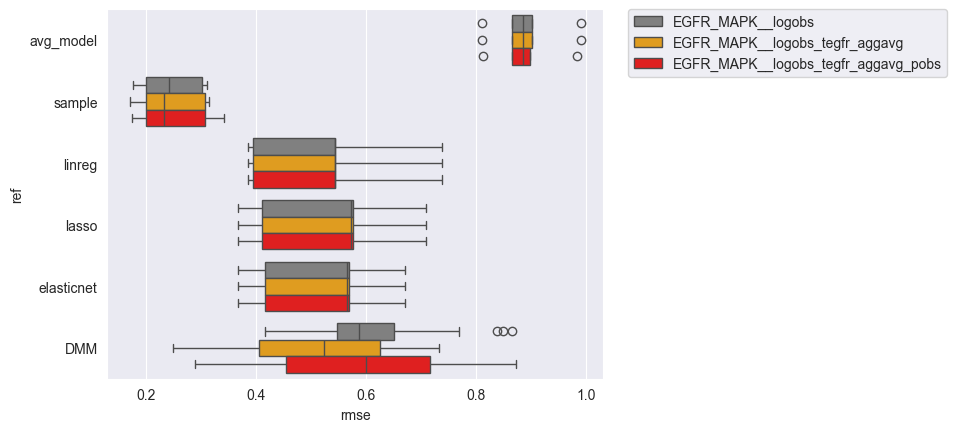

In [3]:
palette = {
    "EGFR_MAPK__logobs": "gray",
    "EGFR_MAPK__logobs_tegfr_aggavg": "orange",
    "EGFR_MAPK__logobs_tegfr_aggavg_pobs": "red",
}

sns.boxplot(
    val_df,
    y="ref",
    x="rmse",
    order=["avg_model", "sample", "linreg", "lasso", "elasticnet", "DMM"],
    hue="model",
    palette=palette
)

plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

# Let's zoom in on DMMs only (regressors are not affected by model choice), comparing model/context combos

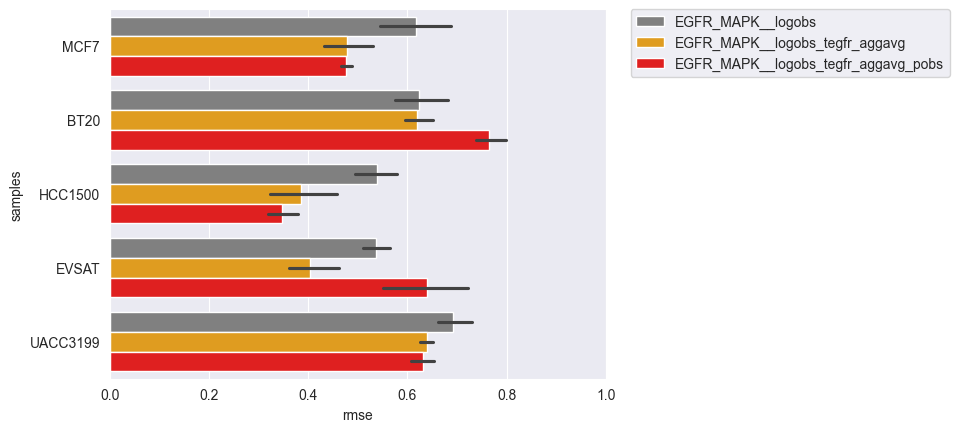

In [4]:
palette = {
    "EGFR_MAPK__logobs": "gray",
    "EGFR_MAPK__logobs_tegfr_aggavg": "orange",
    "EGFR_MAPK__logobs_tegfr_aggavg_pobs": "red",
}

sns.barplot(
    val_df[val_df.ref == "DMM"],
    y="samples",
    x="rmse",
    order=["MCF7", "BT20", "HCC1500", "EVSAT", "UACC3199"],
    hue="model",
    palette=palette
)
plt.xlim([0, 1])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

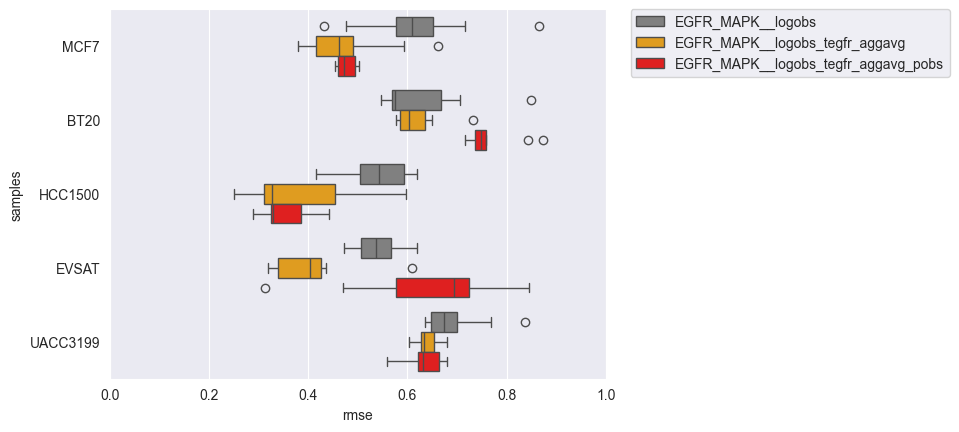

In [5]:
palette = {
    "EGFR_MAPK__logobs": "gray",
    "EGFR_MAPK__logobs_tegfr_aggavg": "orange",
    "EGFR_MAPK__logobs_tegfr_aggavg_pobs": "red",
}

sns.boxplot(
    val_df[val_df.ref == "DMM"],
    y="samples",
    x="rmse",
    order=["MCF7", "BT20", "HCC1500", "EVSAT", "UACC3199"],
    hue="model",
    palette=palette
)
plt.xlim([0, 1])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

# `_tegfr` does something different from adding tEGFR to cytof_init - now HCC-1500 and EVSA-T are the ones which improve quite dramatically, followed by UACC-3199, but not really by BT-20, which was our original target...not even the `avg_model` improves on BT-20 with the added `_tegfr` modification..

In [6]:
val_df[val_df.samples == "BT20"].groupby(["model", "ref"]).rmse.mean()

model                                ref       
EGFR_MAPK__logobs                    DMM           0.623201
                                     avg_model     0.865491
                                     elasticnet    0.565474
                                     lasso         0.572285
                                     linreg        0.542606
                                     sample        0.301176
EGFR_MAPK__logobs_tegfr_aggavg       DMM           0.618930
                                     avg_model     0.865491
                                     elasticnet    0.565474
                                     lasso         0.572285
                                     linreg        0.542606
                                     sample        0.306555
EGFR_MAPK__logobs_tegfr_aggavg_pobs  DMM           0.765132
                                     avg_model     0.864489
                                     elasticnet    0.565474
                                     lasso         0

# Let's restrict to `__logobs_tegr_aggavg` and compare with baselines and regressors

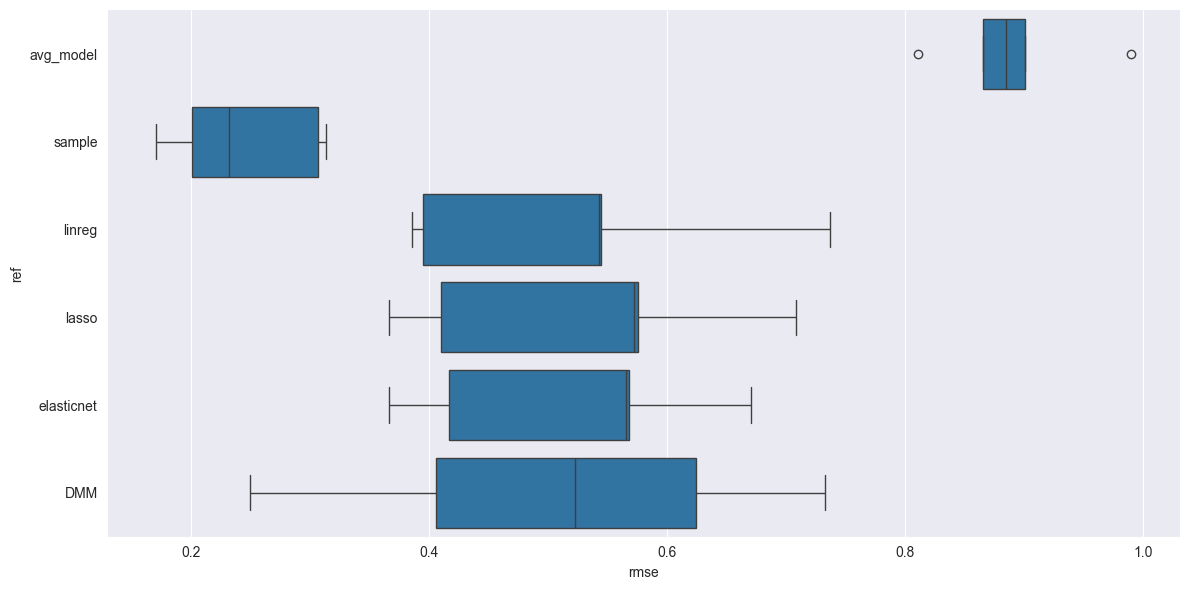

In [7]:
g = sns.FacetGrid(
    val_df[val_df.model == "EGFR_MAPK__logobs_tegfr_aggavg"],
    height=6,
    aspect=2
)

g.map_dataframe(
    sns.boxplot,
    y="ref",
    x="rmse",
    order=["avg_model", "sample", "linreg", "lasso", "elasticnet", "DMM"],
)

In [8]:
from scipy import stats

def kruskal_wallis_groups(df, target_metric, group_metric):
    for context in df['context'].unique():
        context_data = df[df['context'] == context]
        groups = [group[target_metric].values for _, group in context_data.groupby(group_metric)]
        stat, p_value = stats.kruskal(*groups)
        print(f"Context: {context} - Kruskal-Wallis H-test: H-statistic={stat:.2f}, p-value={p_value:.4f}")

# There is a statistically significant difference (improvement) from `__logobs` to `__logobs_tegfr_aggavg`, but not to `__logobs_tegfr_aggavg_pobs`

In [9]:
kruskal_wallis_groups(
    val_df[(val_df.ref.isin(["DMM"])) & (val_df.model.isin(["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"]))],
    "rmse",
    "model"
)

Context: cytof_init - Kruskal-Wallis H-test: H-statistic=8.87, p-value=0.0029


In [10]:
groups = [
    val_df[(val_df.ref.isin(["DMM"])) & (val_df.model.isin(["EGFR_MAPK__logobs",]))].sort_values(by="job").rmse.values,
    val_df[(val_df.ref.isin(["DMM"])) & (val_df.model.isin(["EGFR_MAPK__logobs_tegfr_aggavg",]))].sort_values(by="job").rmse.values,
]
stat, p = stats.wilcoxon(*groups, alternative="two-sided")
print(f"Wilcoxon signed-rank: W={stat}, p={p:.4g}")

Wilcoxon signed-rank: W=191.0, p=5.07e-06


In [11]:
kruskal_wallis_groups(
    val_df[(val_df.ref.isin(["DMM"])) & (val_df.model.isin(["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg_pobs"]))],
    "rmse",
    "model"
)

Context: cytof_init - Kruskal-Wallis H-test: H-statistic=0.36, p-value=0.5487


In [12]:
groups = [
    val_df[(val_df.ref.isin(["DMM"])) & (val_df.model.isin(["EGFR_MAPK__logobs",]))].sort_values(by="job").rmse.values,
    val_df[(val_df.ref.isin(["DMM"])) & (val_df.model.isin(["EGFR_MAPK__logobs_tegfr_aggavg_pobs",]))].sort_values(by="job").rmse.values,
]
stat, p = stats.wilcoxon(*groups, alternative="two-sided")
print(f"Wilcoxon signed-rank: W={stat}, p={p:.4g}")

Wilcoxon signed-rank: W=522.0, p=0.2695


# We can now compare the tEGFR modification to the fEGFR with added tEGFR via context

In [13]:
from training_configuration import PATHWAYS_2A

data = "dream_cytof"
filename2= "evaluate_all_figure2a"

df2 = pd.concat(
    pd.read_csv(EVALUATE_ALL_CSVS.format(model=model, data=data, filename=filename2), index_col=0).assign(model=model)
    for model in PATHWAYS_2A
)
val_df2 = df2[df2.dataset == "val"]
val_df2.features.fillna("None", inplace=True)

In [14]:
val_df2_fegfr_cytof_tegfr = val_df2[(val_df2.context == "cytof_init_plus_tEGFR") & (val_df2.model == "EGFR_MAPK__logobs_fegfr_aggavg")]

In [15]:
df_comp = pd.concat(
    [
        val_df[val_df.model.isin(["EGFR_MAPK__logobs_tegfr_aggavg"])],
        val_df2_fegfr_cytof_tegfr
    ]
)

In [16]:
groups = [
    df_comp[(df_comp.ref.isin(["DMM"])) & (df_comp.context.isin(["cytof_init"])) & (df_comp.model.isin(["EGFR_MAPK__logobs_tegfr_aggavg",]))].sort_values(by="job").rmse.values,
    df_comp[(df_comp.ref.isin(["DMM"])) & (df_comp.context.isin(["cytof_init_plus_tEGFR"])) & (df_comp.model.isin(["EGFR_MAPK__logobs_fegfr_aggavg",]))].sort_values(by="job").rmse.values,
]
stat, p = stats.wilcoxon(*groups, alternative="two-sided")
print(f"Wilcoxon signed-rank: W={stat}, p={p:.4g}")

Wilcoxon signed-rank: W=478.0, p=0.1256


# There is no statistical difference, but embedding tEGFR levels in the mechanistic model performs slightly better than passing them as input context. We can also see that the tEGFR information is helpful to regressors, as their performance drops when moving from `fEGFR` with added tEGFR context to `tEGFR` without it.

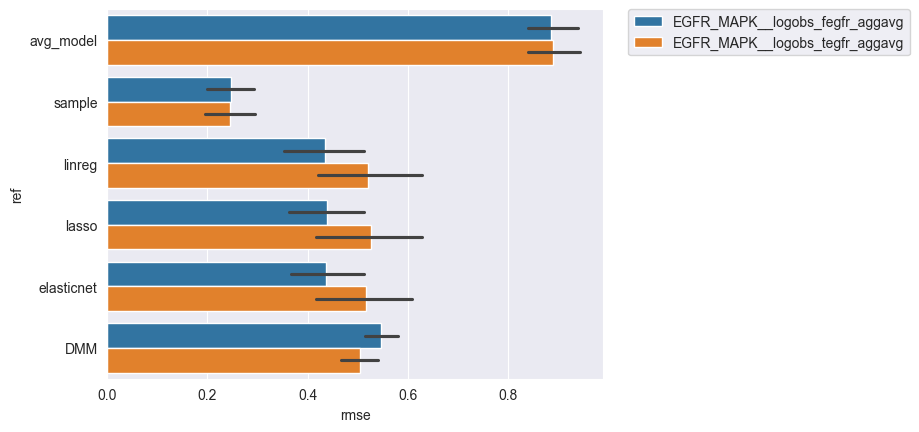

In [17]:
sns.barplot(
    df_comp,
    y="ref",
    x="rmse",
    order=["avg_model", "sample", "linreg", "lasso", "elasticnet", "DMM"],
    hue="model",
    hue_order=["EGFR_MAPK__logobs_fegfr_aggavg", "EGFR_MAPK__logobs_tegfr_aggavg"],
)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

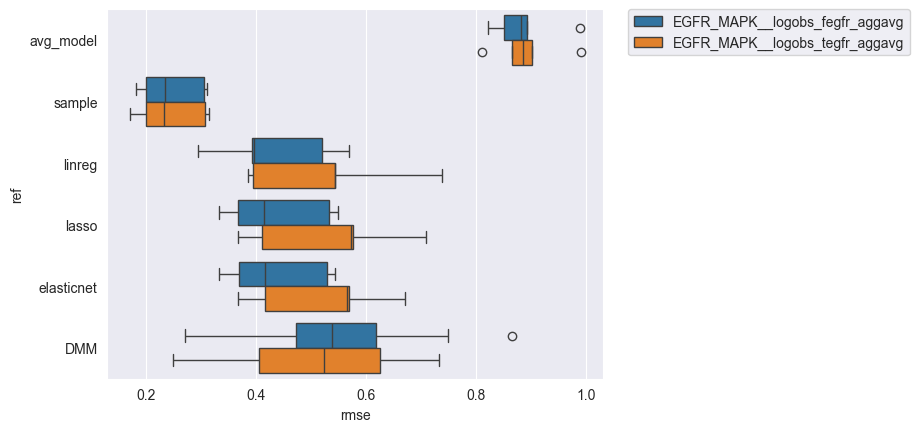

In [18]:
sns.boxplot(
    df_comp,
    y="ref",
    x="rmse",
    order=["avg_model", "sample", "linreg", "lasso", "elasticnet", "DMM"],
    hue="model",
    hue_order=["EGFR_MAPK__logobs_fegfr_aggavg", "EGFR_MAPK__logobs_tegfr_aggavg"],
)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

In [19]:
groups = [
    df_comp[(df_comp.ref.isin(["DMM"])) & (df_comp.context.isin(["cytof_init"])) & (df_comp.model.isin(["EGFR_MAPK__logobs_tegfr_aggavg",]))].groupby("samples").rmse.mean().reset_index().sort_values(by="samples").rmse.values,
    df_comp[(df_comp.ref.isin(["elasticnet"])) & (df_comp.context.isin(["cytof_init_plus_tEGFR"])) & (df_comp.model.isin(["EGFR_MAPK__logobs_fegfr_aggavg",]))].sort_values(by="samples").rmse.values,
]
stat, p = stats.wilcoxon(*groups, alternative="two-sided")
print(f"Wilcoxon signed-rank: W={stat}, p={p:.4g}")

Wilcoxon signed-rank: W=4.0, p=0.4375


# No statistically significant difference between elasticnet with added tEGFR and DMMs without (but tEGFR in mechanistic model)

# Embeddings

In [20]:
from common import evaluations_dir

embedding_df = pd.concat(
    [
        pd.read_csv(evaluations_dir / model / data/ "embeddings_figure3.csv", index_col=0).assign(model=model)
        for model in PATHWAYS_3
    ]
)

In [21]:
from embedding_utils import perform_pca_on_embeddings

pca_embeddings_dict = {}
for model in PATHWAYS_3:
    print(model)
    pca_embeddings_dict[model], _ = perform_pca_on_embeddings(embedding_df[embedding_df.model == model])

EGFR_MAPK__logobs
Explained variance for cytof_init BT20: 0.9097
Explained variance for cytof_init EVSAT: 0.9659
Explained variance for cytof_init HCC1500: 0.9384
Explained variance for cytof_init MCF7: 0.9363
Explained variance for cytof_init UACC3199: 0.9776
EGFR_MAPK__logobs_tegfr_aggavg
Explained variance for cytof_init BT20: 0.9151
Explained variance for cytof_init EVSAT: 0.8985
Explained variance for cytof_init HCC1500: 0.8893
Explained variance for cytof_init MCF7: 0.8910
Explained variance for cytof_init UACC3199: 0.9502
EGFR_MAPK__logobs_tegfr_aggavg_pobs
Explained variance for cytof_init BT20: 0.9236
Explained variance for cytof_init EVSAT: 0.9284
Explained variance for cytof_init HCC1500: 0.9465
Explained variance for cytof_init MCF7: 0.9590
Explained variance for cytof_init UACC3199: 0.8948


In [22]:
import warnings
from common import basedir

warnings.filterwarnings("ignore")

subtypes_marcotte = pd.read_csv(basedir / "cell_line_subtypes.txt", delimiter='\t')
subtypes_marcotte["cell_line"] = subtypes_marcotte["cell_line"].apply(lambda x: "c"+x.upper())
subtypes_marcotte.cell_line.replace("cHS578T", "cHs578T", inplace=True)
subtypes_marcotte.cell_line.replace("c600MPE", "cMPE600", inplace=True)
subtypes_marcotte.sort_values(by="cell_line", inplace=True)
subtypes_marcotte.set_index("cell_line", inplace=True)
subtypes_marcotte = subtypes_marcotte.loc[pca_embeddings_dict["EGFR_MAPK__logobs"].index.unique()]

In [23]:
for model in PATHWAYS_3:
    pca_embeddings_dict[model]["subtype_intrinsic"] = subtypes_marcotte["subtype_intrinsic"]
    pca_embeddings_dict[model]["luminalbasal"] = pca_embeddings_dict[model]["subtype_intrinsic"]
    pca_embeddings_dict[model]["luminalbasal"].replace(["LuminalA", "LuminalB", "HER2"], "Luminal", inplace=True)
    pca_embeddings_dict[model]["luminalbasal"].replace(["CL"], "Basal", inplace=True)

In [24]:
pca_embeddings_df = pd.concat(
    [
        pca_embeddings_dict[model].assign(model=model)
        for model in PATHWAYS_3
    ]
)

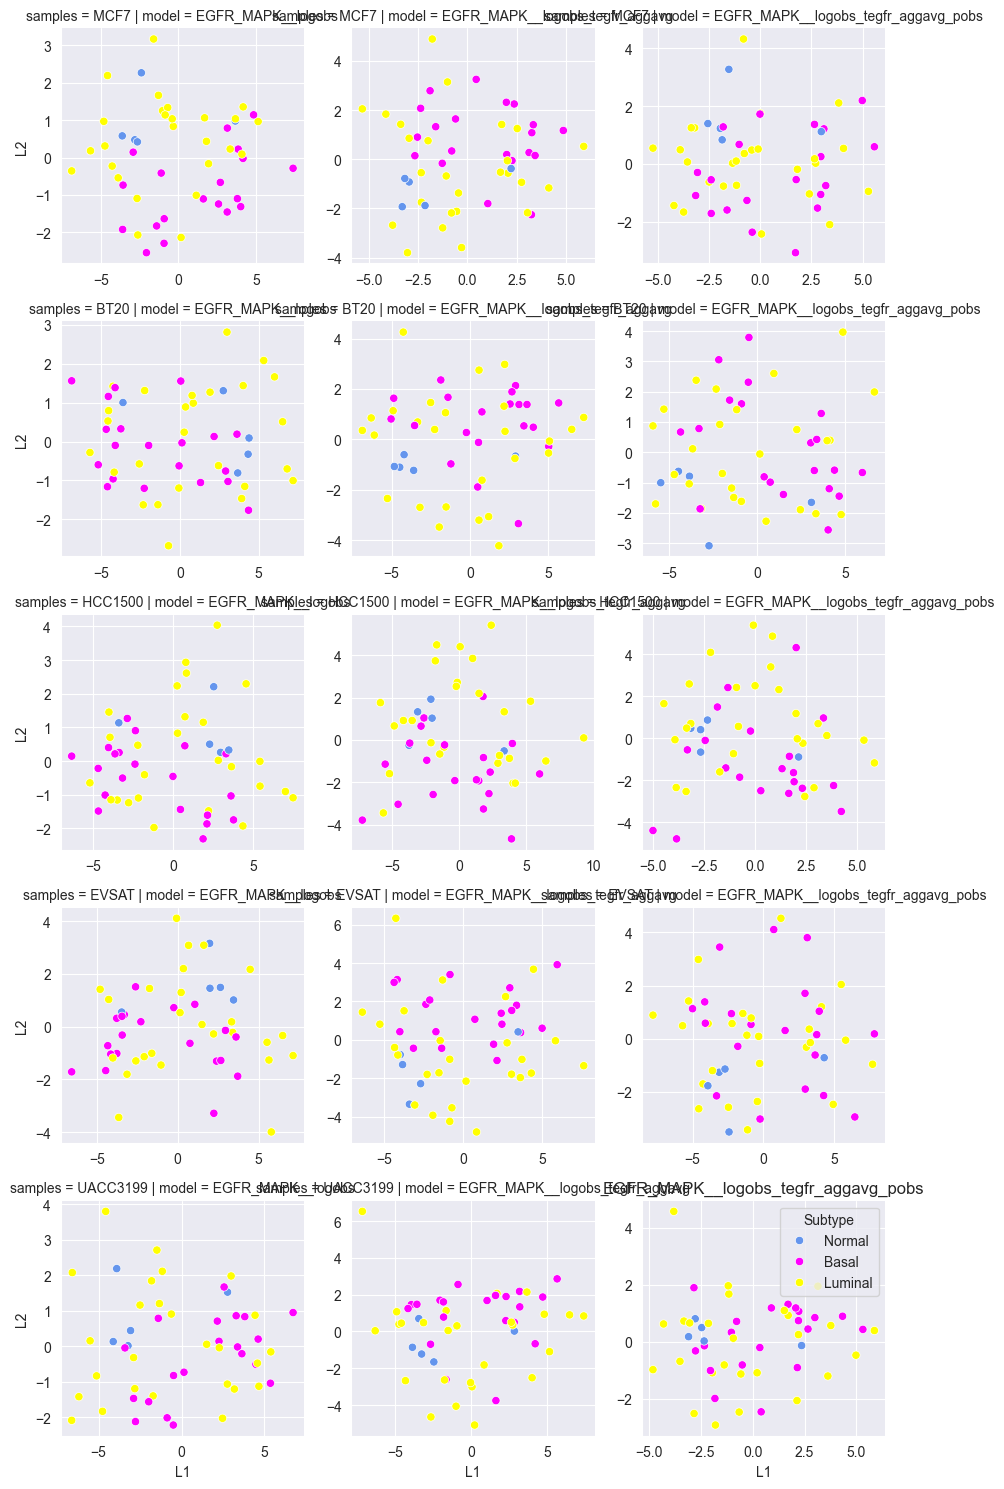

In [25]:
g = sns.FacetGrid(
    pca_embeddings_df,
    row="samples",
    row_order=["MCF7", "BT20", "HCC1500", "EVSAT", "UACC3199"],
    col="model",
    col_order=["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg", "EGFR_MAPK__logobs_tegfr_aggavg_pobs"],
    sharex=False,
    sharey=False
)

g.map_dataframe(
    sns.scatterplot,
    x="L1",
    y="L2",
    hue="luminalbasal",
    palette={
        "Luminal": "yellow",
        "Basal": "magenta",
        "Normal": "cornflowerblue"
    }
)

plt.title(model)

plt.legend(title="Subtype")
plt.show()

EGFR_MAPK__logobs cytof_init
0.31686507936507935


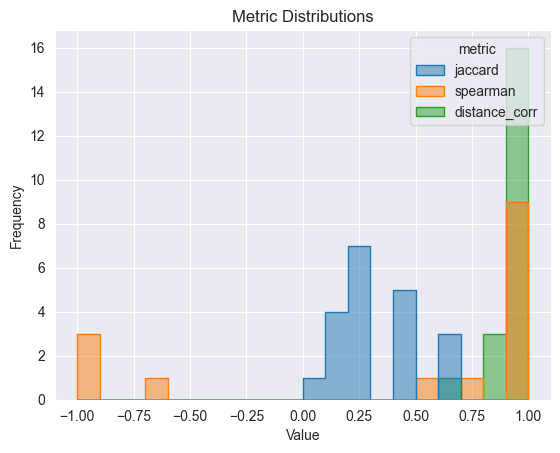

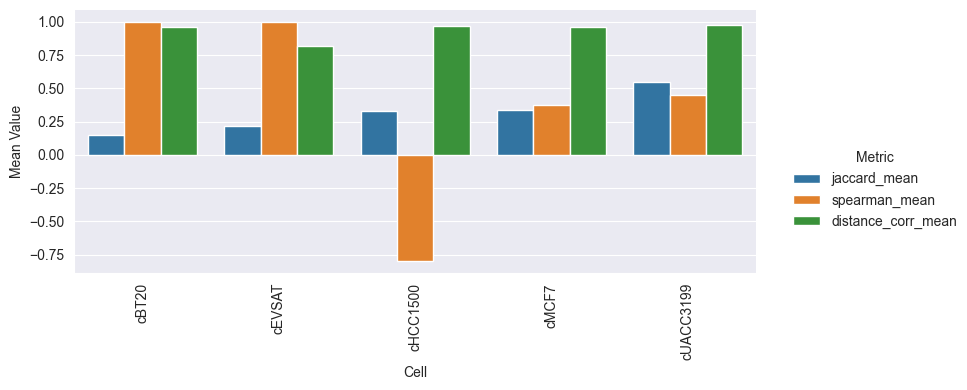

EGFR_MAPK__logobs_tegfr_aggavg cytof_init
0.36448412698412697


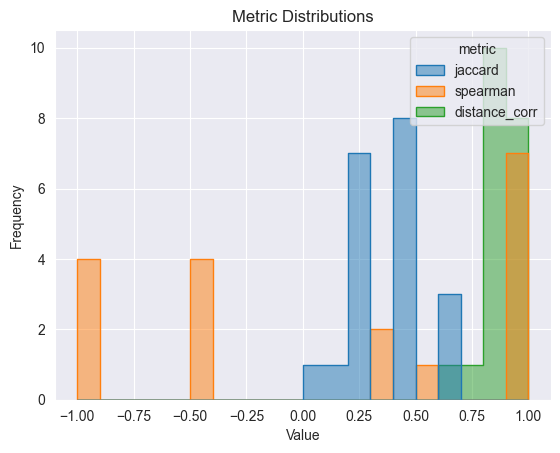

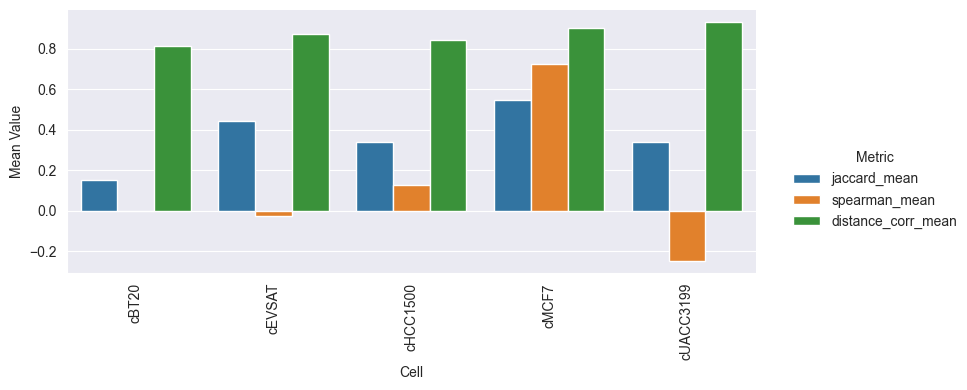

EGFR_MAPK__logobs_tegfr_aggavg_pobs cytof_init
0.23928571428571427


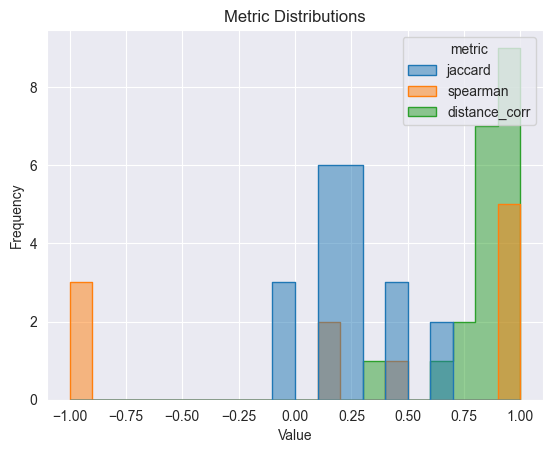

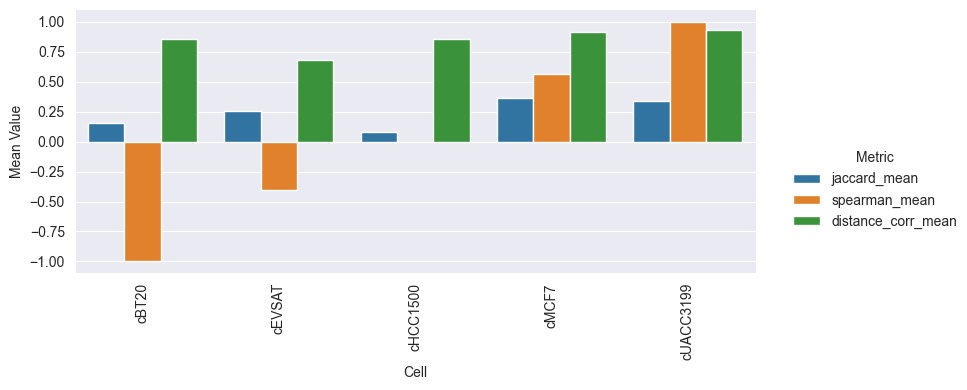

In [26]:
import itertools as itt
from embedding_consistency import *
from training_configuration import CONTEXTS_FEATURES_3

# Compute per (split vs other_split) comparisons for each validation cell
splits = ["MCF7", "BT20", "HCC1500", "EVSAT", "UACC3199"]

summaries = []
for model, (context, _) in itt.product(PATHWAYS_3, CONTEXTS_FEATURES_3):
    print(model, context)
    per_pair = compute_validation_neighborhood_consistency(
        {split: pca_embeddings_dict[model][(pca_embeddings_dict[model]["samples"] == split) & (pca_embeddings_dict[model].context == context)][["L1", "L2"]] for split in splits},
        {split: "c"+split for split in splits},
        n_neighbors=5,      # set N here
        metric="euclidean",  # or "cosine"
    )

    # Summaries per cell
    summary = summarize_consistency(per_pair)
    print(summary.jaccard_mean.mean())
    summaries.append(summary.assign(model=model, context=context))

    plot_distribution(per_pair)
    plot_per_cell_summary(summary)

overall_summary = pd.concat(summaries)

In [27]:
overall_summary.groupby(["model", "context"]).agg({"jaccard_mean": "mean", "spearman_mean": "mean", "distance_corr_mean": "mean"})

,,jaccard_mean,spearman_mean,distance_corr_mean
model,context,,,
EGFR_MAPK__logobs,cytof_init,0.316865,0.405000,0.936955
EGFR_MAPK__logobs_tegfr_aggavg,cytof_init,0.364484,0.115000,0.871201
EGFR_MAPK__logobs_tegfr_aggavg_pobs,cytof_init,0.239286,0.041667,0.848368


# It seems like the mean Jaccard across samples and jobs is considerbaly lower in the case of tEGFR model compared to previous fEGFR with tEGFR levels provided as input features (from 0.55 down to 0.36). Mean Spearman correlation is also down considerably, and mean distance correlation is worse as well...what is going on?
- In particular, we see that BT20 is doing badly consistency-wise compared to the previous models (figure 2a).
- We can also see that the embeddings do not seem to cluster according to / align with luminal/basal subtype anymore, since the EGFR information has been embedded into the mechanistic model...

# Trying to make sense of parameter deviations - PCA-ing across jobs/multistarts and investigating differences between train/val on val cell-lines

In [28]:
import itertools as itt
from common import evaluations_dir
from sklearn.decomposition import PCA

par_dev_df = pd.concat(
    [
        pd.read_csv(evaluations_dir / model / data/ "param_devs_figure3.csv", index_col=0).assign(model=model)
        for model in PATHWAYS_3
    ]
)

not_param_cols = [
    "cell_line", "context", "model", "features", "samples", "dataset", "l1reg_inflater_output", "inflater_output_reg_epoch", "recon_loss", "inflater_bound", "n_epoch", "job"
]
param_cols = [col for col in par_dev_df.columns if col not in not_param_cols]

median_par_dev_df = par_dev_df.groupby(["context", "features", "cell_line", "samples"])[param_cols].median().reset_index()


def pca_param_devs(par_dev_df):
    results_dfs = []
    for ctxt, split in itt.product(par_dev_df.context.unique(), par_dev_df.samples.unique()):
        sub_df = par_dev_df[(par_dev_df.context == ctxt) & (par_dev_df.samples == split)]
        # Compute median across job/multistart
        sub_df = sub_df.groupby(["context", "samples", "cell_line"])[param_cols].median().reset_index()
        sub_df.set_index("cell_line", inplace=True)
        pca = PCA(n_components=2)
        temp_res = pd.DataFrame(
            pca.fit_transform(sub_df[param_cols]),
            sub_df.index,
            columns=["PC1", "PC2"]
        ).assign(context=ctxt, samples=split)
        results_dfs.append(temp_res)
    return pd.concat(results_dfs)

pca_param_df = pd.concat(
    [
        pca_param_devs(par_dev_df[par_dev_df.model == model]).assign(model=model)
        for model in PATHWAYS_3
    ]
)

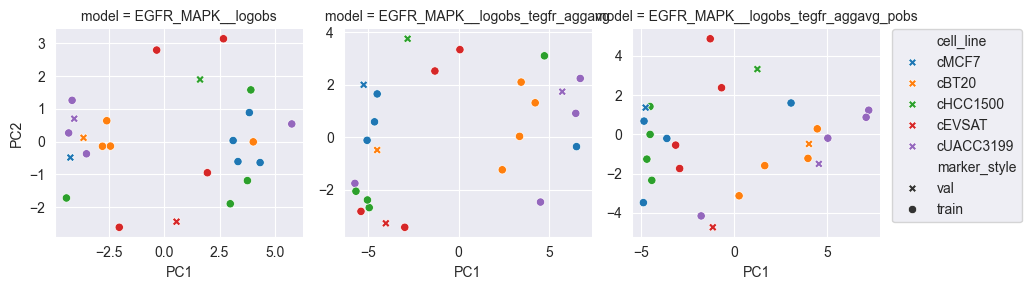

In [29]:
# Add a new column for marker style
pca_param_df["marker_style"] = pca_param_df.apply(
    lambda row: "val" if row.name[1:] == row["samples"] else "train",
    axis=1
)

# Define marker mapping
marker_dict = {"val": "X", "train": "o"}  # X for validation, circle otherwise

g = sns.FacetGrid(
    pca_param_df[pca_param_df.index.isin(["cMCF7", "cBT20", "cHCC1500", "cEVSAT", "cUACC3199"])],
    col="model",
    col_order=["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg", "EGFR_MAPK__logobs_tegfr_aggavg_pobs"],
    sharex=False,
    sharey=False
)

g.map_dataframe(
    sns.scatterplot,
    x="PC1",
    y="PC2",
    hue="cell_line",
    style="marker_style",        # use the new column for marker
    markers=marker_dict,         # assign specific markers
    hue_order=["cMCF7", "cBT20", "cHCC1500", "cEVSAT", "cUACC3199"]
)

plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()